# Simulation — Ideal Conditions

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Fixed-N simulation (continuous data, ML)

Under ideal conditions: continuous multivariate normal data, ML estimator. This should converge with the analytical results from semPower/semTools.

In [ ]:

sim_ideal_fixed <- run_sim(
  nRep     = REP,
  n        = 500,
  model    = analyzeModel,
  generate = popModel
)


The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
           Alpha
Fit Indices       0.1      0.05      0.01     0.001      Mean      SD
      chisq   281.053   292.242   315.741   326.518   250.888  25.684
      aic   27512.919 27563.484 27613.343 27622.032 27309.308 143.867
      bic   27744.723 27795.287 27845.146 27853.836 27541.111 143.867
      rmsea     0.017     0.020     0.024     0.026     0.007   0.007
      cfi       0.995     0.993     0.990     0.989     0.998   0.003
      tli       0.994     0.992     0.988     0.987     0.999   0.004
      srmr      0.033     0.034     0.035     0.035     0.030   0.002
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.917       0.034      0.034
psycho=~Q6                       0.807       0.040      0.037
psycho=~Q7                       0.940       0.031      0.034
psycho=~Q11                    

## Varying-N simulation — Power curve

In [ ]:

sim_ideal_vary <- run_sim(
  nRep     = NULL,
  n        = SEQ,
  model    = analyzeModel,
  generate = popModel
)

summary(sim_ideal_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
    N   chisq       aic       bic rmsea   cfi   tli  srmr
1 100 298.104  5878.811  6042.462 0.038 0.975 0.972 0.065
2 225 292.468 12628.755 12813.149 0.031 0.981 0.979 0.055
3 350 286.833 19378.698 19583.836 0.024 0.987 0.985 0.046
4 475 281.197 26128.641 26354.523 0.017 0.993 0.992 0.036
5 600 275.561 32878.585 33125.209 0.010 0.999 0.999 0.026
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.918       0.049      0.045
psycho=~Q6                       0.819       0.054      0.049
psycho=~Q7                       0.944       0.048      0.044
psycho=~Q11                      0.742       0.057      0.051
psycho=~Q19                      0.749       0.044      0.050
psycho=~Q26                      0.630       0.060      0.053
physical=~Q3                     0.827       0.055      0.048
physical=~Q4

## Power for parameters

In [ ]:

# Extract power for each parameter across N values
ideal_power <- getPower(sim_ideal_vary, alpha = ALPHA)

# Find the minimum N for 80% power across all parameters
findPower(ideal_power, "N", POWER)


           psycho=~Q5            psycho=~Q6            psycho=~Q7 
                  Inf                   Inf                   Inf 
          psycho=~Q11           psycho=~Q19           psycho=~Q26 
                  Inf                   Inf                   Inf 
         physical=~Q3          physical=~Q4         physical=~Q10 
                  Inf                   Inf                   Inf 
        physical=~Q15         physical=~Q16         physical=~Q17 
                  Inf                   Inf                   Inf 
        physical=~Q18           social=~Q20           social=~Q21 
                  Inf                   Inf                   Inf 
          social=~Q22       environment=~Q8       environment=~Q9 
                  Inf                   Inf                   Inf 
     environment=~Q12      environment=~Q13      environment=~Q14 
                  Inf                   Inf                   Inf 
     environment=~Q23      environment=~Q24      environment=~

## Power to detect good fit (fit index cutoffs)

In [ ]:

# Power that fit indices fall within rule-of-thumb cutoffs at selected N values
cat("--- Power at N = 300 ---\n")


--- Power at N = 300 ---

     cfi      tli    rmsea     srmr 
"< 0.48" "< 0.42" "< 0.46" "< 0.42" 


--- Power at N = 500 ---

     cfi      tli    rmsea     srmr 
"< 0.48" "< 0.48" "< 0.46" "< 0.42" 


--- Power at N = 1000 ---

     cfi      tli    rmsea     srmr 
"< 0.42" "< 0.48" "< 0.46" "< 0.48" 

## Fit index sampling distributions

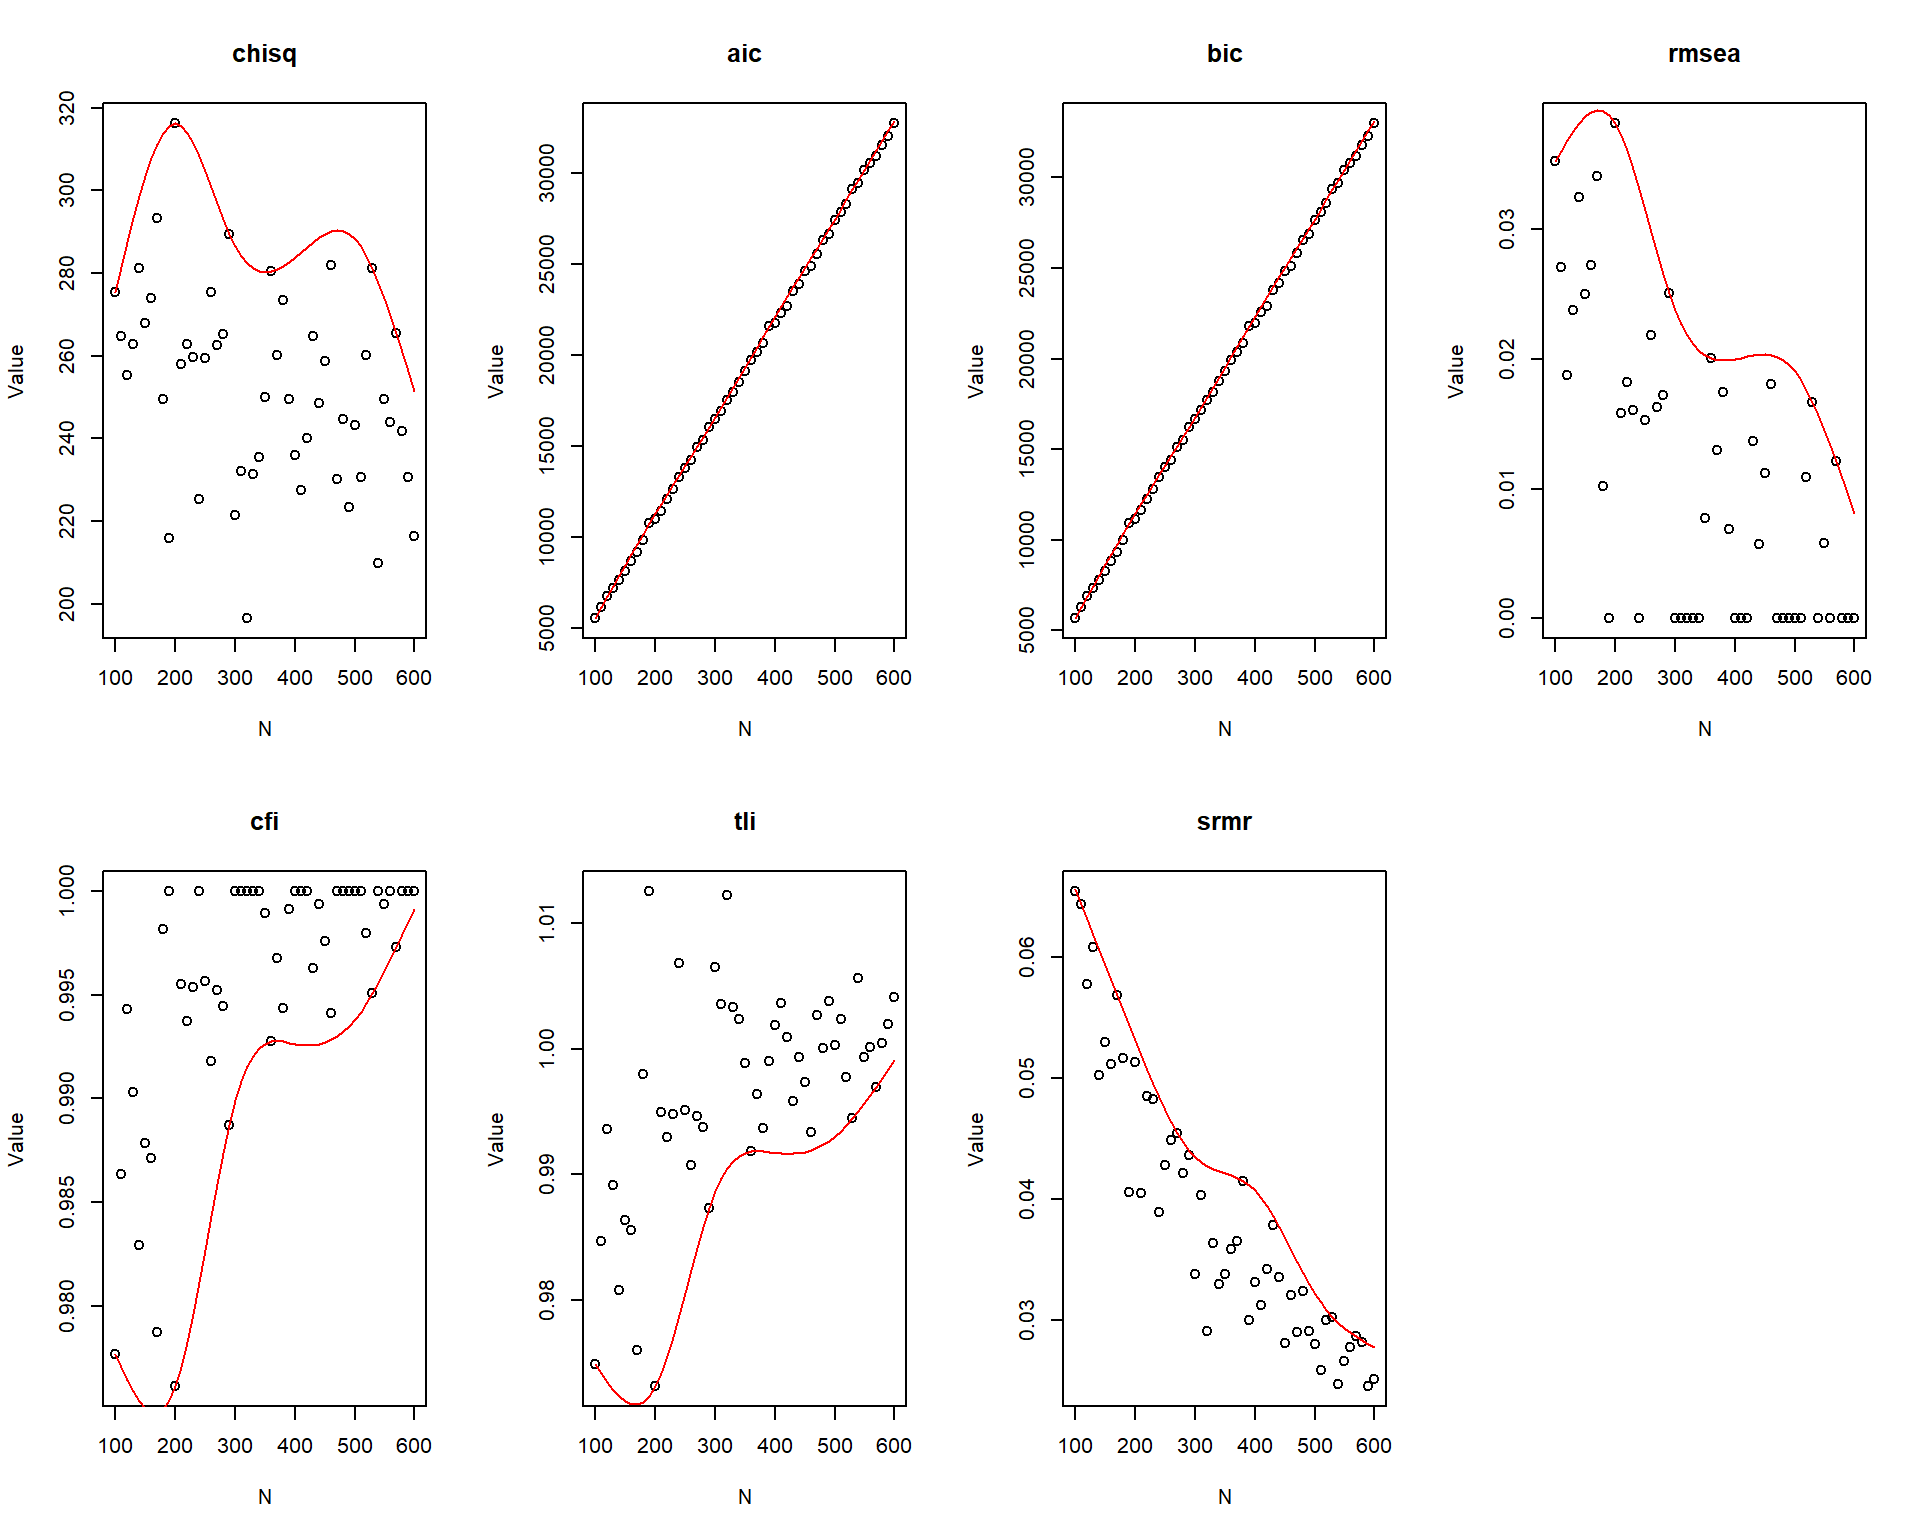

In [ ]:

plotCutoff(sim_ideal_vary, alpha = ALPHA)


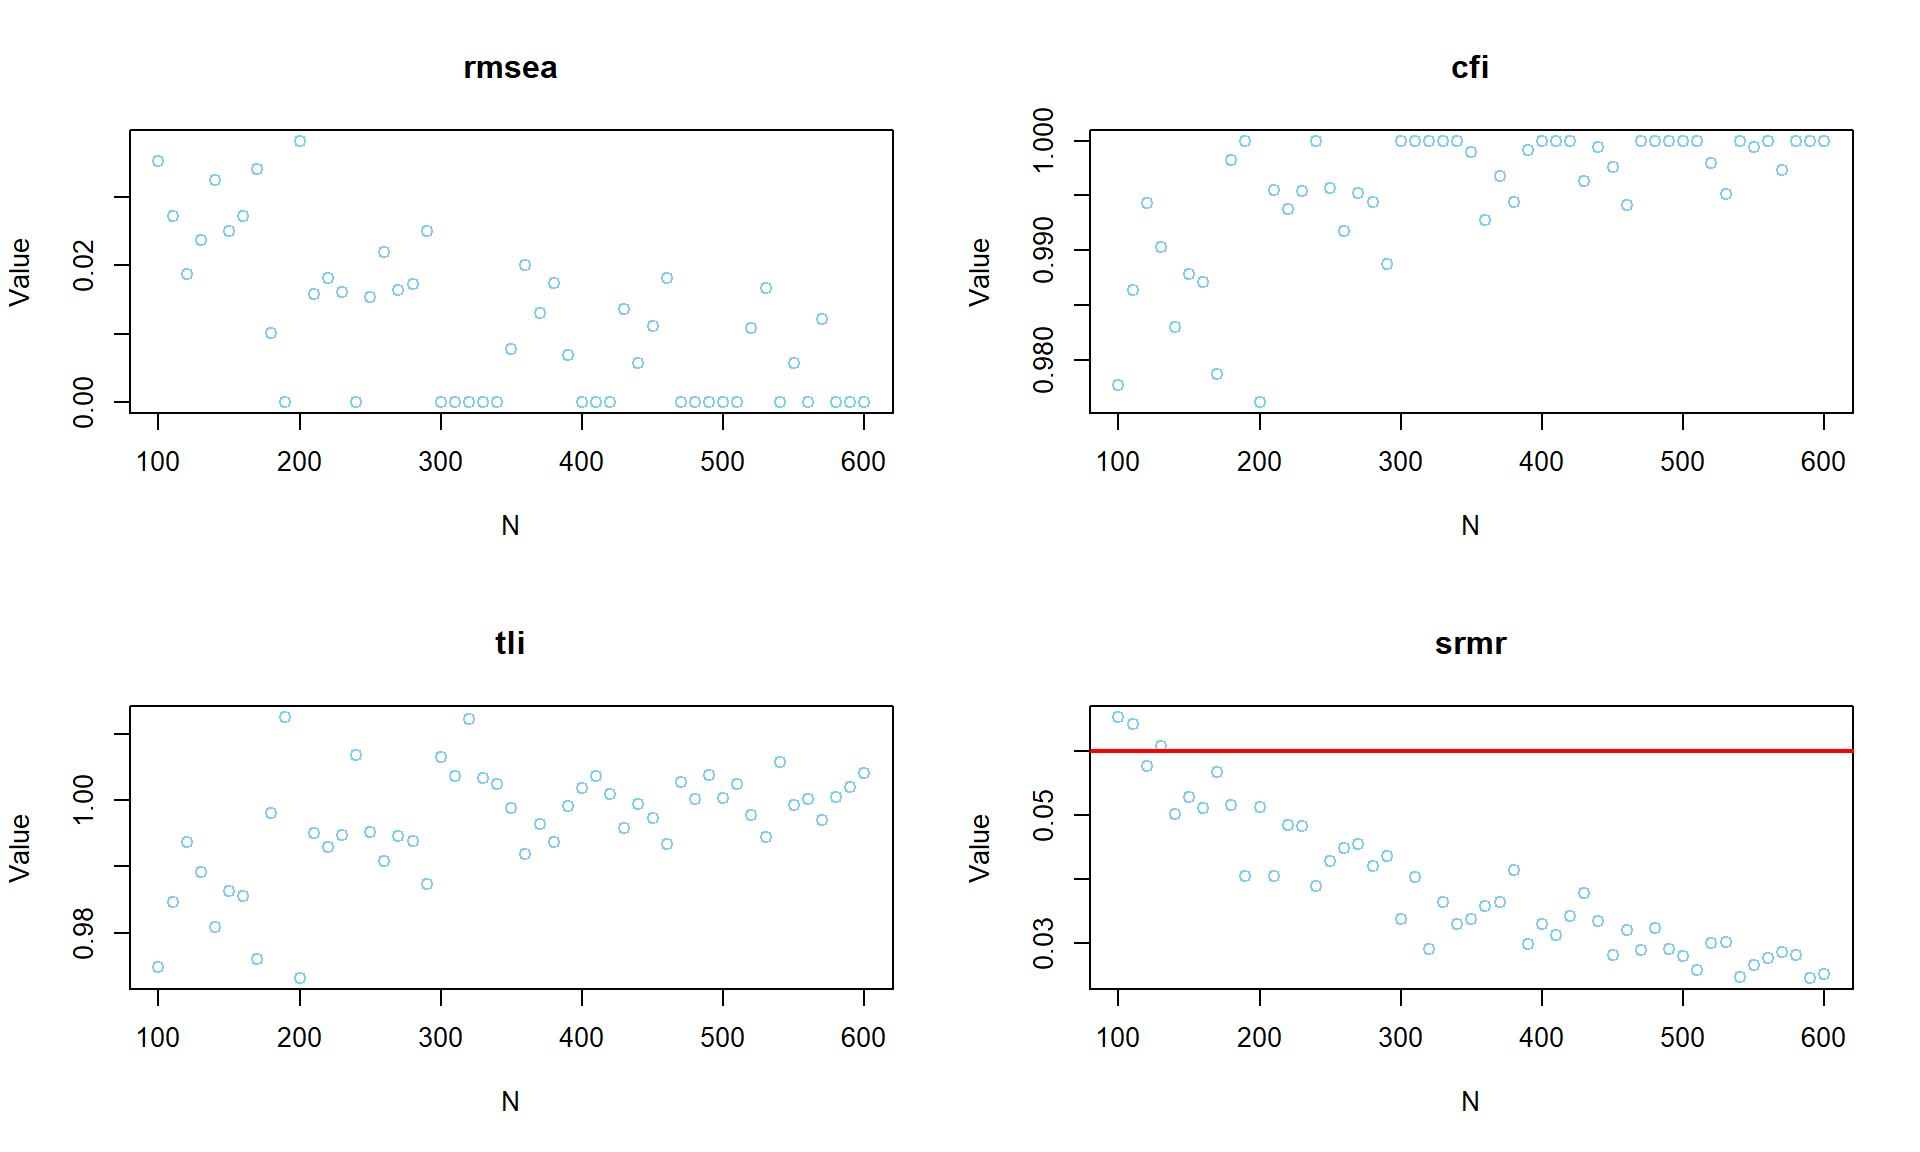

In [ ]:

plotPowerFit(sim_ideal_vary, cutoff = RULE_OF_THUMB, logistic = FALSE)


## Parameter-level summary

In [ ]:

param_summary <- summaryParam(sim_ideal_fixed, detail = TRUE, digits = 3)
kable(param_summary)


  -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                              Estimate   Estimate   Average   Power Std Est Std Est Std Ave   Average   Average   Coverage Rel Bias Std Bias   Rel SE     Not     Not   Average   SD CI
                               Average         SD        SE    (Not              SD      SE     Param      Bias                                  Bias   Cover   Cover  CI Width   Width
                                                              equal                                                                                     Below   Above           
                                                                 0)                                                                                                             
  ------------------------- ---------- ---------- --------- ------- ------- ------- ------- --------- --------- ---------- -------- -------- -------- ------- ------- --------- -------
  psycho=\~Q5                    0.917      0.034     0.034    1.00   0.920   0.010   0.009     0.920    -0.003       0.92   -0.003   -0.095    0.026    0.02    0.06     0.135   0.004

  psycho=\~Q6                    0.807      0.040     0.037    1.00   0.810   0.019   0.017     0.810    -0.003       0.88   -0.004   -0.073   -0.074    0.02    0.10     0.145   0.004

  psycho=\~Q7                    0.940      0.031     0.034    1.00   0.941   0.009   0.008     0.940     0.000       0.96    0.000   -0.005    0.093    0.02    0.02     0.133   0.004

  psycho=\~Q11                   0.732      0.040     0.039    1.00   0.730   0.022   0.022     0.730     0.002       0.96    0.003    0.046   -0.031    0.04    0.00     0.153   0.004

  psycho=\~Q19                   0.748      0.035     0.039    1.00   0.749   0.018   0.021     0.750    -0.002       0.98   -0.003   -0.063    0.094    0.00    0.02     0.151   0.004

  psycho=\~Q26                   0.627      0.049     0.041    1.00   0.631   0.033   0.028     0.630    -0.003       0.88   -0.004   -0.053   -0.176    0.04    0.08     0.159   0.004

  physical=\~Q3                  0.841      0.036     0.037    1.00   0.844   0.016   0.017     0.840     0.001       0.96    0.001    0.021    0.039    0.02    0.02     0.146   0.004

  physical=\~Q4                  0.829      0.036     0.038    1.00   0.831   0.018   0.017     0.830    -0.001       0.96   -0.001   -0.034    0.043    0.02    0.02     0.147   0.004

  physical=\~Q10                 0.623      0.035     0.042    1.00   0.625   0.025   0.029     0.630    -0.007       0.98   -0.011   -0.206    0.188    0.00    0.02     0.163   0.004

  physical=\~Q15                 0.712      0.039     0.040    1.00   0.711   0.022   0.024     0.710     0.002       0.98    0.003    0.055    0.026    0.00    0.02     0.157   0.005

  physical=\~Q16                 0.685      0.039     0.041    1.00   0.681   0.029   0.026     0.680     0.005       0.98    0.008    0.137    0.051    0.00    0.02     0.160   0.004

  physical=\~Q17                 0.892      0.041     0.036    1.00   0.890   0.013   0.013     0.890     0.002       0.88    0.002    0.052   -0.110    0.02    0.10     0.141   0.004

  physical=\~Q18                 0.611      0.044     0.042    1.00   0.610   0.032   0.030     0.610     0.001       0.94    0.002    0.031   -0.056    0.02    0.04     0.164   0.005

  social=\~Q20                   0.942      0.040     0.035    1.00   0.939   0.012   0.012     0.940     0.002       0.94    0.003    0.059   -0.122    0.02    0.04     0.138   0.004

  social=\~Q21                   0.896      0.037     0.036    1.00   0.891   0.014   0.014     0.890     0.006       0.96    0.007    0.175   -0.006    0.00    0.04     0.143   0.004

  social=\~Q22                   0.782      0.040     0.038    1.00   0.782   0.019   0.020     0.780     0.002       0.92    0.003    0.058   -0.050    0.04    0.04     0.151   0.004

  environment=\~Q8               0.363      0.049     0.046    1.00   0.362   0.044   0.041     0.370    -0.007       0.94   -0.020   -0.152   -0.072    0.02    0.04     0.179   0.005

  environment=\~Q9               0.481      0.040     0.044    1.00   0.483   0.032   0.037     0.490    -0.009       0.98   -0.019   -0.230    0.106    0.00    0.02     0.172   0.006

  environment=\~Q12              0.777      0.040     0.039    1.00   0.782   0.021   0.021     0.790    -0.013       0.94   -0.016   -0.327   -0.027    0.00    0.06     0.152   0.004

  environment=\~Q13              0.807      0.041     0.038    1.00   0.812   0.018   0.019     0.810    -0.003       0.94   -0.004   -0.082   -0.064    0.02    0.04     0.149   0.004

  environment=\~Q14              0.769      0.039     0.039    1.00   0.770   0.022   0.021     0.770    -0.001       0.96   -0.002   -0.033    0.012    0.00    0.04     0.153   0.004

  environment=\~Q23              0.741      0.033     0.040    1.00   0.745   0.019   0.023     0.750    -0.009       0.96   -0.012   -0.269    0.194    0.00    0.04     0.155   0.004

  environment=\~Q24              0.616      0.042     0.042    1.00   0.621   0.028   0.030     0.640    -0.024       0.92   -0.038   -0.579   -0.005    0.00    0.08     0.164   0.005

  environment=\~Q25              0.728      0.035     0.040    1.00   0.731   0.022   0.024     0.730    -0.002       0.98   -0.002   -0.049    0.127    0.00    0.02     0.156   0.004

  psycho\~\~physical             0.202      0.053     0.046    1.00   0.202   0.053   0.046     0.200     0.002       0.90    0.010    0.037   -0.122    0.06    0.04     0.181   0.004

  psycho\~\~social               0.206      0.041     0.046    1.00   0.206   0.041   0.046     0.200     0.006       0.98    0.028    0.138    0.115    0.00    0.02     0.179   0.003

  psycho\~\~environment          0.204      0.053     0.047    0.98   0.204   0.053   0.047     0.200     0.004       0.94    0.019    0.070   -0.121    0.04    0.02     0.183   0.004

  physical\~\~social             0.209      0.048     0.046    1.00   0.209   0.048   0.046     0.200     0.009       0.92    0.043    0.179   -0.028    0.06    0.02     0.182   0.004

  physical\~\~environment        0.207      0.053     0.047    0.98   0.207   0.053   0.047     0.200     0.007       0.90    0.034    0.125   -0.113    0.08    0.02     0.186   0.004

  social\~\~environment          0.207      0.040     0.047    1.00   0.207   0.040   0.047     0.200     0.007       0.98    0.037    0.183    0.167    0.02    0.00     0.185   0.003

  Q3\~\~Q4                       0.089      0.023     0.020    1.00   0.297   0.058   0.054     0.091    -0.002       0.92   -0.021   -0.084   -0.103    0.04    0.04     0.080   0.004

  Q5\~\~Q5                       0.153      0.016     0.015    1.00   0.154   0.018   0.017     0.154    -0.001       0.92   -0.005   -0.047   -0.106    0.04    0.04     0.057   0.004

  Q6\~\~Q6                       0.339      0.023     0.024    1.00   0.343   0.031   0.027     0.344    -0.005       0.92   -0.015   -0.219    0.022    0.02    0.06     0.094   0.005

  Q7\~\~Q7                       0.113      0.016     0.013    1.00   0.114   0.016   0.015     0.116    -0.003       0.92   -0.026   -0.193   -0.174    0.02    0.06     0.052   0.003

  Q11\~\~Q11                     0.468      0.031     0.032    1.00   0.466   0.032   0.032     0.467     0.000       0.96    0.001    0.015    0.008    0.00    0.04     0.124   0.008

  Q19\~\~Q19                     0.437      0.027     0.030    1.00   0.439   0.027   0.031     0.438    -0.001       0.98   -0.001   -0.019    0.088    0.00    0.02     0.117   0.007

  Q26\~\~Q26                     0.592      0.032     0.039    1.00   0.601   0.041   0.035     0.603    -0.011       0.94   -0.019   -0.354    0.210    0.00    0.06     0.152   0.008

  Q3\~\~Q3                       0.285      0.026     0.025    1.00   0.287   0.026   0.028     0.294    -0.010       0.92   -0.033   -0.367   -0.043    0.00    0.08     0.098   0.006

  Q4\~\~Q4                       0.308      0.030     0.026    1.00   0.310   0.030   0.029     0.311    -0.003       0.92   -0.011   -0.110   -0.119    0.02    0.06     0.103   0.006

  Q10\~\~Q10                     0.605      0.038     0.041    1.00   0.609   0.031   0.037     0.603     0.002       1.00    0.003    0.052    0.083    0.00    0.00     0.160   0.009

  Q15\~\~Q15                     0.493      0.033     0.035    1.00   0.493   0.031   0.035     0.496    -0.002       0.94   -0.005   -0.072    0.033    0.00    0.06     0.136   0.008

  Q16\~\~Q16                     0.543      0.041     0.037    1.00   0.536   0.039   0.036     0.538     0.005       0.94    0.010    0.130   -0.080    0.00    0.06     0.147   0.010

  Q17\~\~Q17                     0.207      0.020     0.021    1.00   0.207   0.024   0.024     0.208    -0.001       0.96   -0.003   -0.034    0.085    0.02    0.02     0.084   0.005

  Q18\~\~Q18                     0.629      0.046     0.042    1.00   0.627   0.039   0.037     0.628     0.001       0.94    0.001    0.016   -0.081    0.02    0.04     0.165   0.011

  Q20\~\~Q20                     0.119      0.022     0.022    1.00   0.118   0.023   0.023     0.116     0.002       1.00    0.018    0.098    0.015    0.00    0.00     0.086   0.006

  Q21\~\~Q21                     0.208      0.023     0.023    1.00   0.206   0.025   0.025     0.208     0.000       0.94   -0.001   -0.008    0.007    0.04    0.02     0.089   0.005

  Q22\~\~Q22                     0.388      0.028     0.028    1.00   0.389   0.030   0.031     0.392    -0.003       0.92   -0.009   -0.119    0.016    0.00    0.08     0.112   0.007

  Q8\~\~Q8                       0.869      0.053     0.056    1.00   0.867   0.032   0.030     0.863     0.006       0.98    0.007    0.116    0.063    0.02    0.00     0.219   0.013

  Q9\~\~Q9                       0.756      0.052     0.050    1.00   0.765   0.032   0.036     0.760    -0.004       0.94   -0.005   -0.071   -0.037    0.00    0.06     0.194   0.013

  Q12\~\~Q12                     0.383      0.031     0.030    1.00   0.388   0.033   0.032     0.376     0.007       0.96    0.018    0.221   -0.036    0.02    0.02     0.117   0.007

  Q13\~\~Q13                     0.335      0.026     0.028    1.00   0.340   0.029   0.030     0.344    -0.009       0.94   -0.026   -0.337    0.056    0.00    0.06     0.108   0.007

  Q14\~\~Q14                     0.405      0.033     0.031    1.00   0.407   0.034   0.033     0.407    -0.002       0.94   -0.004   -0.054   -0.070    0.00    0.06     0.121   0.008

  Q23\~\~Q23                     0.440      0.028     0.033    1.00   0.445   0.028   0.034     0.438     0.003       1.00    0.007    0.104    0.164    0.00    0.00     0.128   0.007

  Q24\~\~Q24                     0.602      0.037     0.041    1.00   0.614   0.034   0.037     0.590     0.011       1.00    0.019    0.303    0.115    0.00    0.00     0.161   0.009

  Q25\~\~Q25                     0.462      0.032     0.034    1.00   0.466   0.032   0.035     0.467    -0.005       0.96   -0.011   -0.160    0.053    0.00    0.04     0.132   0.008
  -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


## Convergence: Analytical vs. Simulation

In [ ]:

# Note: fill in analytical_n after running 03_analytical_power.qmd
# For now, use placeholder that will be replaced by the embed output
convergence_table <- data.frame(
  Approach = c("semPower a priori (RMSEA ≥ .05)",
               "semTools a priori (RMSEA ≥ .05)",
               "simsem (parameter power, max N)",
               "simsem (fit power at SRMR < .06)"),
  `N for 80% Power` = c(
    "See @sec-apriori",
    "See @sec-apriori",
    "From findPower() above",
    "From getPowerFit() above"
  ),
  Notes = c(
    "Model-free, RMSEA-based",
    "Same underlying math",
    "Continuous/ML, population model",
    "Continuous/ML, population model"
  ),
  check.names = FALSE
)

kable(convergence_table, align = "lll")


  ------------------------------------------------------------------------
  Approach                   N for 80% Power     Notes
  -------------------------- ------------------- -------------------------
  semPower a priori (RMSEA ≥ See @sec-apriori    Model-free, RMSEA-based
  .05)                                           

  semTools a priori (RMSEA ≥ See @sec-apriori    Same underlying math
  .05)                                           

  simsem (parameter power,   From findPower()    Continuous/ML, population
  max N)                     above               model

  simsem (fit power at SRMR  From getPowerFit()  Continuous/ML, population
  \< .06)                    above               model
  ------------------------------------------------------------------------
